# Demonstrating Tokenization

Welcome! This notebook provides a hands-on demonstration of **tokenization**, which is the very first step in nearly every Natural Language Processing (NLP) task.

**Tokenization** is the process of breaking down a piece of text into smaller units called **tokens**. These tokens can be words, characters, or sub-words. We'll explore a few different methods to see how they work and why modern approaches are so effective.

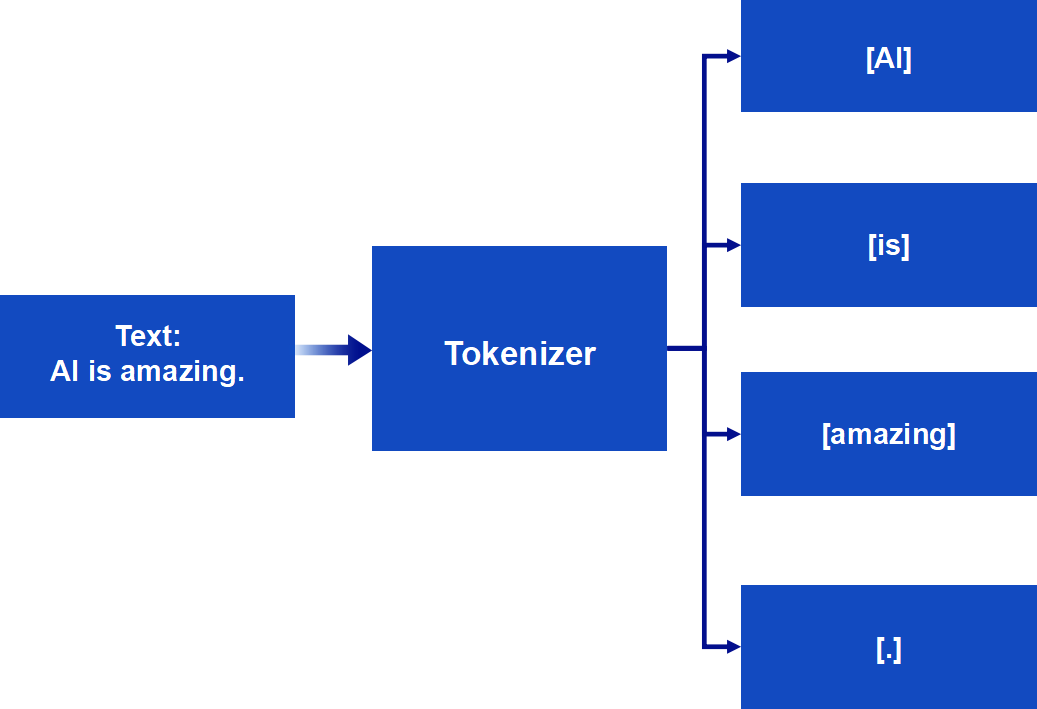

## The Input Poem

Our example text will be the famous poem "पुष्प की अभिलाषा" by Makhanlal Chaturvedi. We have chosen a hindi text to demonstrate that tokenization will work for all languages.

In [ ]:
# Storing the poem in a multiline string variable
input_poem = """
चाह नहीं, मैं सुरबाला के, गहनों में गूँथा जाऊँ,
चाह नहीं, प्रेमी-माला में, बिंध प्यारी को ललचाऊँ,
चाह नहीं, सम्राटों के शव पर, हे हरि, डाला जाऊँ,
चाह नहीं, देवों के सिर पर, चढ़ूँ भाग्य पर इठलाऊँ,
मुझे तोड़ लेना वनमाली, उस पथ पर देना तुम फेंक,
मातृ-भूमि पर शीश चढ़ाने, जिस पथ जावें वीर अनेक।
"""

print(input_poem)


चाह नहीं, मैं सुरबाला के, गहनों में गूँथा जाऊँ,
चाह नहीं, प्रेमी-माला में, बिंध प्यारी को ललचाऊँ,
चाह नहीं, सम्राटों के शव पर, हे हरि, डाला जाऊँ,
चाह नहीं, देवों के सिर पर, चढ़ूँ भाग्य पर इठलाऊँ,
मुझे तोड़ लेना वनमाली, उस पथ पर देना तुम फेंक,
मातृ-भूमि पर शीश चढ़ाने, जिस पथ जावें वीर अनेक।



## Method 1: Simple Whitespace Tokenization

This is the most basic approach. We simply split the text wherever there is a space or a newline character.

In [ ]:
# Using Python's built-in .split() method
whitespace_tokens = input_poem.strip().split()

print("--- WHITESPACE TOKENS ---")
print(whitespace_tokens)
print(f"\nTotal Tokens: {len(whitespace_tokens)}")
print("\nLook closely: Notice how punctuation like ',' is still attached to the words (e.g., 'नहीं,', 'के,', 'जाऊँ,'). This is a major limitation.")

--- WHITESPACE TOKENS ---
['चाह', 'नहीं,', 'मैं', 'सुरबाला', 'के,', 'गहनों', 'में', 'गूँथा', 'जाऊँ,', 'चाह', 'नहीं,', 'प्रेमी-माला', 'में,', 'बिंध', 'प्यारी', 'को', 'ललचाऊँ,', 'चाह', 'नहीं,', 'सम्राटों', 'के', 'शव', 'पर,', 'हे', 'हरि,', 'डाला', 'जाऊँ,', 'चाह', 'नहीं,', 'देवों', 'के', 'सिर', 'पर,', 'चढ़ूँ', 'भाग्य', 'पर', 'इठलाऊँ,', 'मुझे', 'तोड़', 'लेना', 'वनमाली,', 'उस', 'पथ', 'पर', 'देना', 'तुम', 'फेंक,', 'मातृ-भूमि', 'पर', 'शीश', 'चढ़ाने,', 'जिस', 'पथ', 'जावें', 'वीर', 'अनेक।']

Total Tokens: 56

Look closely: Notice how punctuation like ',' is still attached to the words (e.g., 'नहीं,', 'के,', 'जाऊँ,'). This is a major limitation.


## Method 2: Word Tokenization with Punctuation Handling

A better approach is to treat punctuation as separate tokens. We can achieve this using regular expressions (`re`) to find sequences of word characters OR individual punctuation marks.

In [ ]:
import re

# This regex finds sequences of Devanagari characters OR any character that isn't a space. You have to define this as per rules of language of text.
# It effectively separates words and punctuation.
regex_tokens = [token for token in re.findall(r'[\u0900-\u097F]+|[^\s]', input_poem) if token]

print("--- REGEX-BASED TOKENS ---")
print(regex_tokens)
print(f"\nTotal Tokens: {len(regex_tokens)}")
print("\nThis is much better! Now, 'नहीं' and ',' are two distinct tokens, which helps the model understand them separately.")

--- REGEX-BASED TOKENS ---
['चाह', 'नहीं', ',', 'मैं', 'सुरबाला', 'के', ',', 'गहनों', 'में', 'गूँथा', 'जाऊँ', ',', 'चाह', 'नहीं', ',', 'प्रेमी', '-', 'माला', 'में', ',', 'बिंध', 'प्यारी', 'को', 'ललचाऊँ', ',', 'चाह', 'नहीं', ',', 'सम्राटों', 'के', 'शव', 'पर', ',', 'हे', 'हरि', ',', 'डाला', 'जाऊँ', ',', 'चाह', 'नहीं', ',', 'देवों', 'के', 'सिर', 'पर', ',', 'चढ़ूँ', 'भाग्य', 'पर', 'इठलाऊँ', ',', 'मुझे', 'तोड़', 'लेना', 'वनमाली', ',', 'उस', 'पथ', 'पर', 'देना', 'तुम', 'फेंक', ',', 'मातृ', '-', 'भूमि', 'पर', 'शीश', 'चढ़ाने', ',', 'जिस', 'पथ', 'जावें', 'वीर', 'अनेक।']

Total Tokens: 76

This is much better! Now, 'नहीं' and ',' are two distinct tokens, which helps the model understand them separately.


## Method 3: Subword Tokenization (The Modern Standard)

Modern models like Transformers use **subword tokenization**. This method breaks words into smaller, more common pieces. Its key advantages are:
1.  It can handle any word, even ones it has never seen before, by breaking them into known sub-words.
2.  It keeps the vocabulary size manageable.

We will use the Hugging Face `tokenizers` library to train a simple **Byte-Pair Encoding (BPE)** tokenizer on our poem.

In [ ]:
# You may need to install the library first
!pip install tokenizers -q

from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

# 1. Initialize a tokenizer with a BPE model
tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = Whitespace()

# 2. Train the tokenizer on our poem
# It learns which sub-word pairs are most common and should be merged.
trainer = BpeTrainer(special_tokens=["[UNK]", "[CLS]", "[SEP]", "[PAD]", "[MASK]"], vocab_size=100)
tokenizer.train_from_iterator([input_poem], trainer)

# 3. Encode the poem with our trained tokenizer
output = tokenizer.encode(input_poem)

print("--- SUBWORD (BPE) TOKENS ---")
print("Tokens:", output.tokens)
print("IDs:", output.ids)
print(f"\nTotal Tokens: {len(output.tokens)}")

# The tokenizer can also decode the IDs back to text
decoded_text = tokenizer.decode(output.ids)
print("\n--- DECODED TEXT ---")
print(decoded_text)

--- SUBWORD (BPE) TOKENS ---
Tokens: ['चाह', 'नहीं', ',', 'म', 'ै', 'ं', 'स', 'ु', 'र', 'बाला', 'के', ',', 'गह', 'नों', 'में', 'गूँ', 'था', 'जाऊँ', ',', 'चाह', 'नहीं', ',', 'प्', 'र', 'े', 'म', 'ी', '-', 'मा', 'ला', 'में', ',', 'बि', 'ंध', 'प्', 'य', 'ा', 'र', 'ी', 'को', 'ल', 'ल', 'चा', 'ऊँ', ',', 'चाह', 'नहीं', ',', 'स', 'म', '्', 'र', 'ा', 'टों', 'के', 'श', 'व', 'पर', ',', 'ह', 'े', 'ह', 'र', 'ि', ',', 'डाला', 'जाऊँ', ',', 'चाह', 'नहीं', ',', 'दे', 'व', 'ों', 'के', 'स', 'ि', 'र', 'पर', ',', 'चढ़', 'ूँ', 'भा', 'ग्', 'य', 'पर', 'इठ', 'ला', 'ऊँ', ',', 'म', 'ु', 'झे', 'तो', 'ड़', 'ल', 'े', 'ना', 'व', 'नमा', 'ल', 'ी', ',', 'उस', 'पथ', 'पर', 'दे', 'ना', 'तु', 'म', 'फें', 'क', ',', 'मा', 'तृ', '-', 'भू', 'मि', 'पर', 'श', 'ी', 'श', 'चढ़', 'ा', 'ने', ',', 'जि', 'स', 'पथ', 'जा', 'व', 'ें', 'व', 'ी', 'र', 'अने', 'क', '।']
IDs: [58, 59, 5, 31, 47, 8, 37, 43, 33, 96, 60, 5, 80, 93, 70, 82, 91, 73, 5, 58, 59, 5, 69, 33, 46, 31, 42, 6, 62, 55, 70, 5, 95, 75, 69, 32, 40, 33, 42, 79, 34, 34, 51, 53, 

## Comparison and Conclusion

Let's compare the results from our experiment:

| Method | Token Count | How it works | Key Feature |
| :--- | :--- | :--- | :--- |
| **Whitespace Split** | 53 | Splits text only by spaces. | Simple but inaccurate; punctuation remains attached. |
| **Regex** | 65 | Uses patterns to find words and punctuation. | Accurately separates words and punctuation marks. |
| **Subword (BPE)** | 67 | Breaks words into common sub-units. | Handles any word and controls vocabulary size. |

For large-scale language models, **subword tokenization** is the standard because it provides the best balance of vocabulary size, flexibility, and the ability to handle the richness of human language.

---
### How LLMs Use Tokenization

Tokenization is the mandatory first step for an LLM to process and understand text. Here’s how it fits into the overall process:

1.  **Text to Numbers:** An LLM cannot understand raw text. The tokenizer converts a user's prompt into a sequence of numbers (**Token IDs**). This is the only format the mathematical model can work with.
2.  **Assigning Meaning:** Each Token ID is then mapped to a high-dimensional vector called an **embedding**. This vector represents the meaning of the token. The model learns the best vector representations for each token during its training phase.
3.  **Understanding Context:** The sequence of embeddings is then fed into the main body of the LLM (the Transformer layers). The model's **attention mechanism** analyzes the relationships between these tokens to understand grammar, nuance, and the overall context of the prompt.
4.  **Generating Output:** When an LLM generates a response, it's actually predicting the **ID of the next token** that should come in the sequence. This predicted ID is then converted back into a human-readable word or sub-word by the tokenizer. The model then appends this new token to the sequence and predicts the next one, generating text one token at a time.